# Task 3: Heart Disease Prediction

This notebook demonstrates how to build a model to predict the risk of heart disease using the UCI Heart Disease dataset. Steps include data cleaning, EDA, model training, evaluation, and feature importance analysis.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and scikit-learn for data handling, visualization, and modeling.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

## 2. Load the Heart Disease Dataset
Load the UCI Heart Disease dataset (CSV file). Update the file path as needed.

In [6]:
# Load the dataset (update the path as needed)
df = pd.read_csv('heart_disease_uci.csv')  # Place heart.csv in the same directory or update the path

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
# Print column names to verify target column
print('Columns:', df.columns.tolist())

target_col = None
for col in df.columns:
    if col.lower() in ['target', 'output', 'diagnosis', 'hd', 'num', 'presence', 'class']:
        target_col = col
        break
if target_col is None:
    raise ValueError('Could not find a target column. Please check your CSV file.')
print('Using target column:', target_col)

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Using target column: num


## 3. Data Cleaning
Check for missing values and handle them if any are found.

In [8]:
# Check for missing values
df.info()
print('Missing values per column:')
print(df.isnull().sum())

# If missing values exist, fill with median (or drop rows)
df = df.fillna(df.median(numeric_only=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol  

## 4. Exploratory Data Analysis (EDA)
Explore the dataset to understand trends and relationships between features and the target variable.

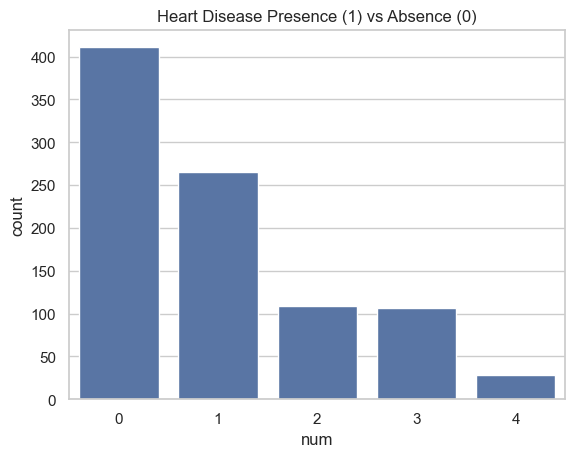

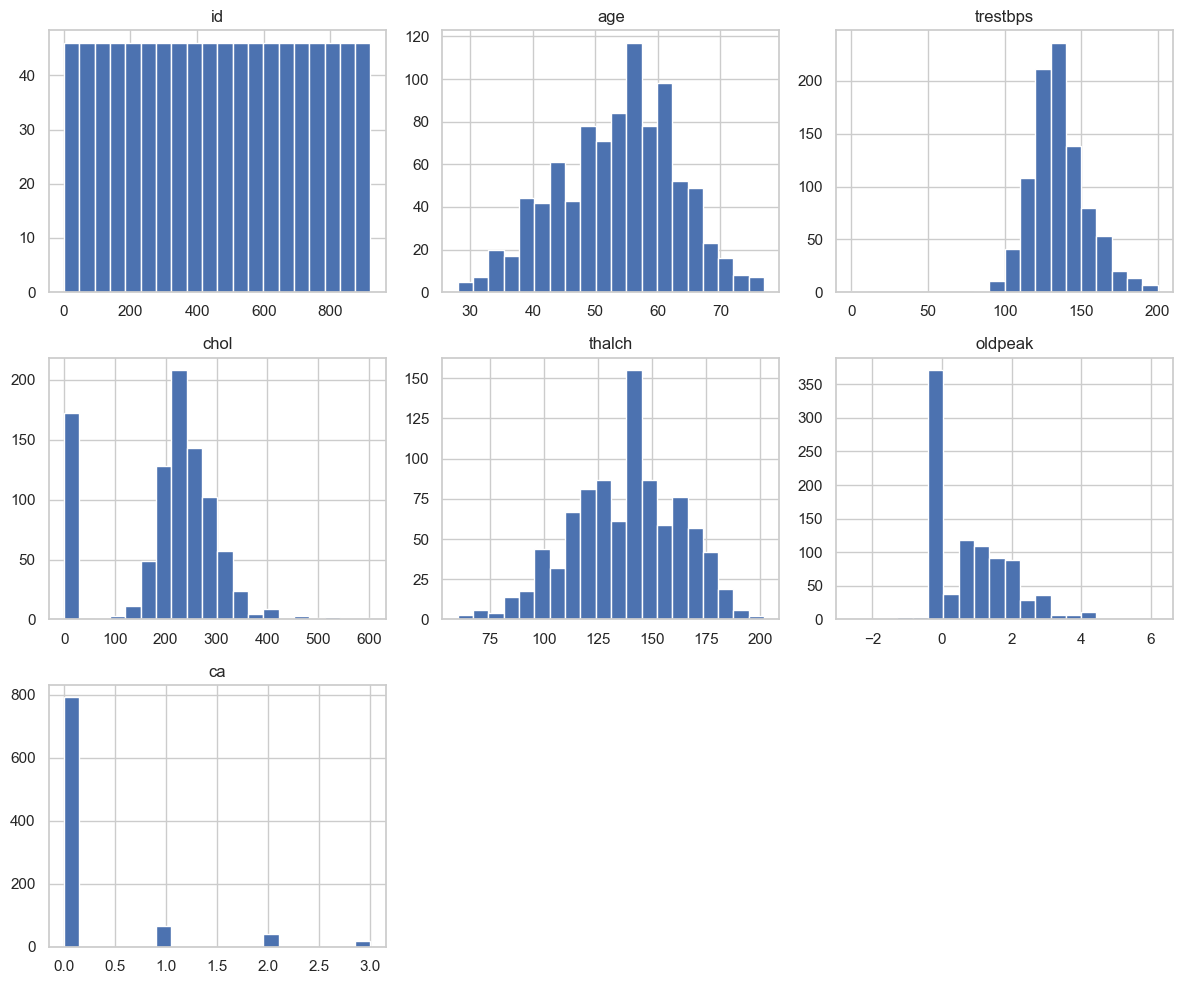

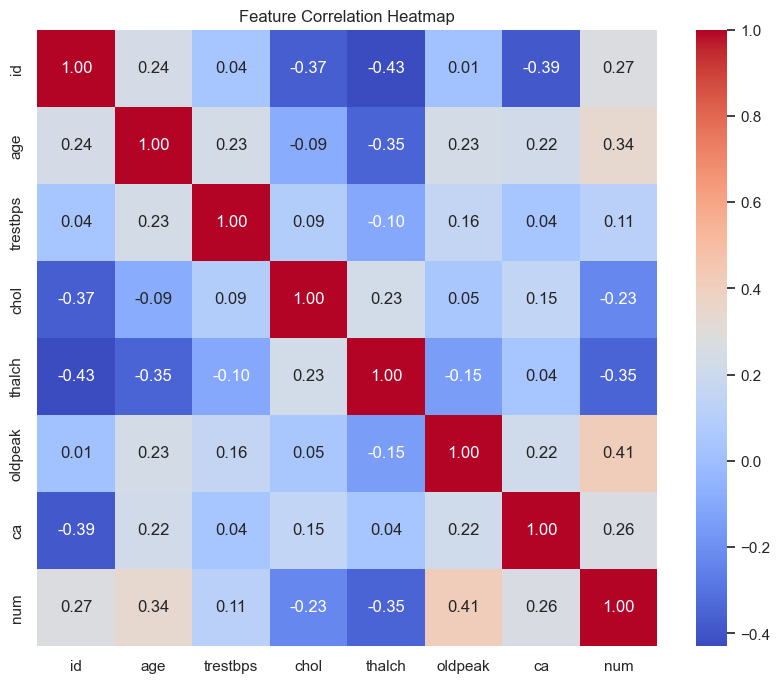

In [10]:
# Class balance
sns.countplot(x=target_col, data=df)
plt.title('Heart Disease Presence (1) vs Absence (0)')
plt.show()

# Feature distributions
features = [col for col in df.columns if col != target_col]
df[features].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Model Training
Train a classification model (Logistic Regression or Decision Tree) to predict heart disease risk.

In [13]:
# One-hot encode categorical columns before splitting features and target
X = df.drop(target_col, axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Show accuracy
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.5543478260869565
Decision Tree Accuracy: 0.5489130434782609


## 6. Model Evaluation
Evaluate the models using accuracy, confusion matrix, ROC curve, and ROC-AUC score.

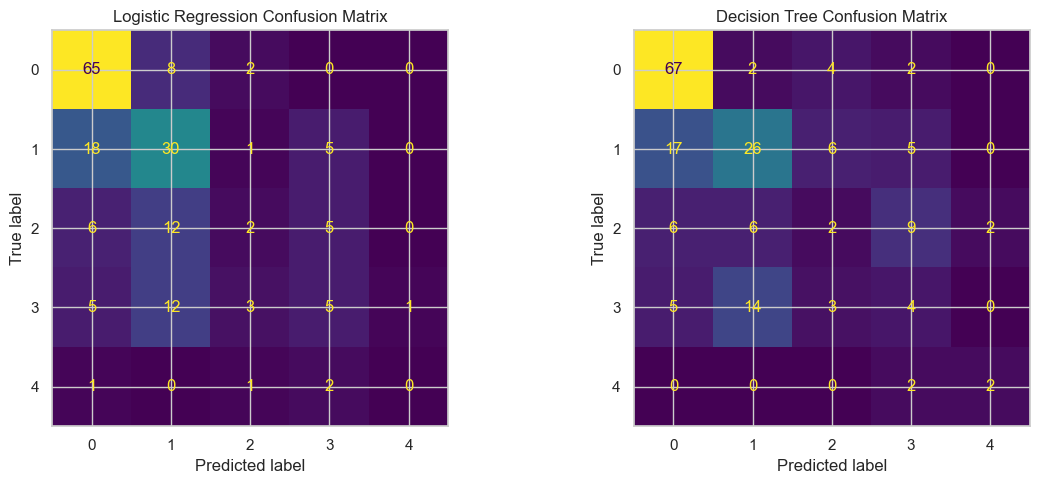

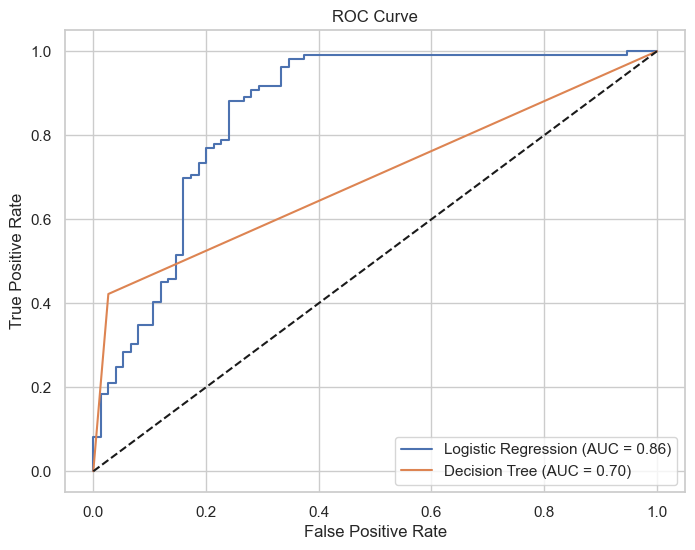

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1], colorbar=False)
axes[1].set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

# Binarize y_test for ROC/AUC (0 = no disease, 1 = disease present)
y_test_bin = (y_test > 0).astype(int)

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, lr.predict_proba(X_test_scaled)[:, 1])
fpr_dt, tpr_dt, _ = roc_curve(y_test_bin, dt.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test_bin, lr.predict_proba(X_test_scaled)[:, 1]):.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test_bin, dt.predict_proba(X_test)[:, 1]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Feature Importance Analysis
Highlight the most important features affecting heart disease prediction.

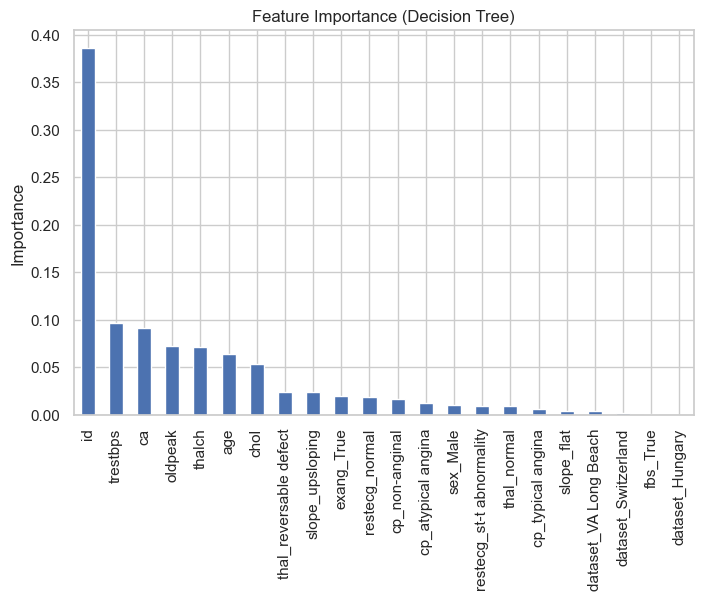

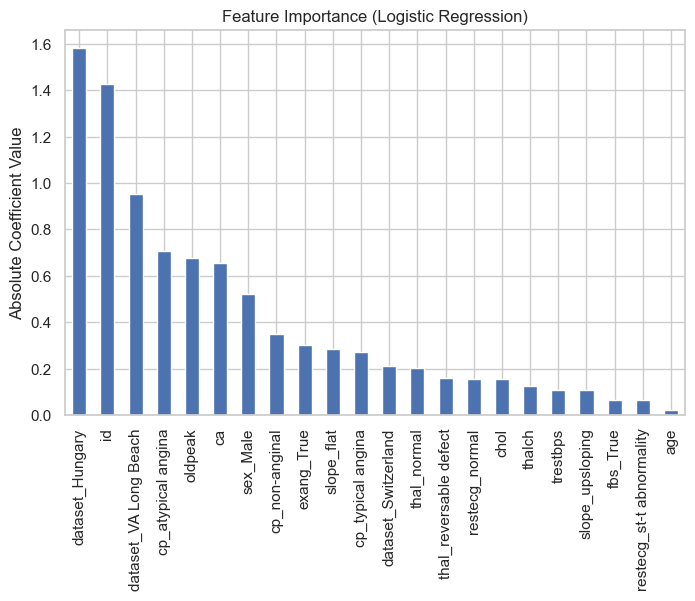

In [16]:
# Feature importance for Decision Tree
importances_dt = pd.Series(dt.feature_importances_, index=X.columns)
importances_dt = importances_dt.sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances_dt.plot(kind='bar')
plt.title('Feature Importance (Decision Tree)')
plt.ylabel('Importance')
plt.show()

# Coefficients for Logistic Regression
coefs_lr = pd.Series(lr.coef_[0], index=X.columns)
coefs_lr = coefs_lr.abs().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
coefs_lr.plot(kind='bar')
plt.title('Feature Importance (Logistic Regression)')
plt.ylabel('Absolute Coefficient Value')
plt.show()